# Hello

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

from src.io_utils import load_sequences_from_folder, build_sequences_info

In [2]:
import pandas as pd

sequences = load_sequences_from_folder("../Data/Base")
info_df = pd.DataFrame(build_sequences_info(sequences))
info_df

,Species,SequenceLength
0,Bos taurus,3766
1,Caenorhabditis elegans,945
2,Canis lupus familiaris,4505
3,Danio rerio,14019
4,Drosophila melanogaster,1149
5,Equus caballus,3972
6,Felis catus,4151
7,Homo sapiens,3863
8,Mesocricetus auratus,3017
9,Mus musculus,5365


In [3]:
from src.similarity import lcs_length

print(lcs_length("AGGTAB", "GXTXAYB"))

4


In [4]:
from src.similarity import similarity_score

species = list(sequences.keys())

seq1 = sequences[species[0]]
seq2 = sequences[species[1]]

print(species[0])
print(species[1])

print(similarity_score(seq1, seq2))

Bos taurus
Caenorhabditis elegans
0.9915343915343915


In [5]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

In [6]:
import pandas as pd

from src.io_utils import load_sequences_from_folder, build_sequences_info
from src.ranking import build_similarity_matrix, build_rank_matrix

In [7]:
sequences = load_sequences_from_folder("../Data/Base")
info_df = pd.DataFrame(build_sequences_info(sequences))
info_df

,Species,SequenceLength
0,Bos taurus,3766
1,Caenorhabditis elegans,945
2,Canis lupus familiaris,4505
3,Danio rerio,14019
4,Drosophila melanogaster,1149
5,Equus caballus,3972
6,Felis catus,4151
7,Homo sapiens,3863
8,Mesocricetus auratus,3017
9,Mus musculus,5365


In [8]:
from src.ranking import build_similarity_matrix, build_rank_matrix

similarity_df = build_similarity_matrix(sequences, use_progress=True)
similarity_df.round(3)

Building similarity matrix:   0%|          | 0/45 [00:00<?, ?it/s]

,Bos taurus,Caenorhabditis elegans,Canis lupus familiaris,Danio rerio,Drosophila melanogaster,Equus caballus,Felis catus,Homo sapiens,Mesocricetus auratus,Mus musculus
Bos taurus,1.000,0.992,0.771,0.979,0.967,0.773,0.747,0.741,0.730,0.760
Caenorhabditis elegans,0.992,1.000,0.999,1.000,0.719,0.994,0.992,0.990,0.943,1.000
Canis lupus familiaris,0.771,0.999,1.000,0.947,0.988,0.760,0.768,0.762,0.771,0.691
Danio rerio,0.979,1.000,0.947,1.000,1.000,0.968,0.960,0.973,0.999,0.902
Drosophila melanogaster,0.967,0.719,0.988,1.000,1.000,0.977,0.974,0.977,0.907,1.000
Equus caballus,0.773,0.994,0.760,0.968,0.977,1.000,0.742,0.753,0.744,0.744
Felis catus,0.747,0.992,0.768,0.960,0.974,0.742,1.000,0.742,0.766,0.719
Homo sapiens,0.741,0.990,0.762,0.973,0.977,0.753,0.742,1.000,0.738,0.751
Mesocricetus auratus,0.730,0.943,0.771,0.999,0.907,0.744,0.766,0.738,1.000,0.846
Mus musculus,0.760,1.000,0.691,0.902,1.000,0.744,0.719,0.751,0.846,1.000


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

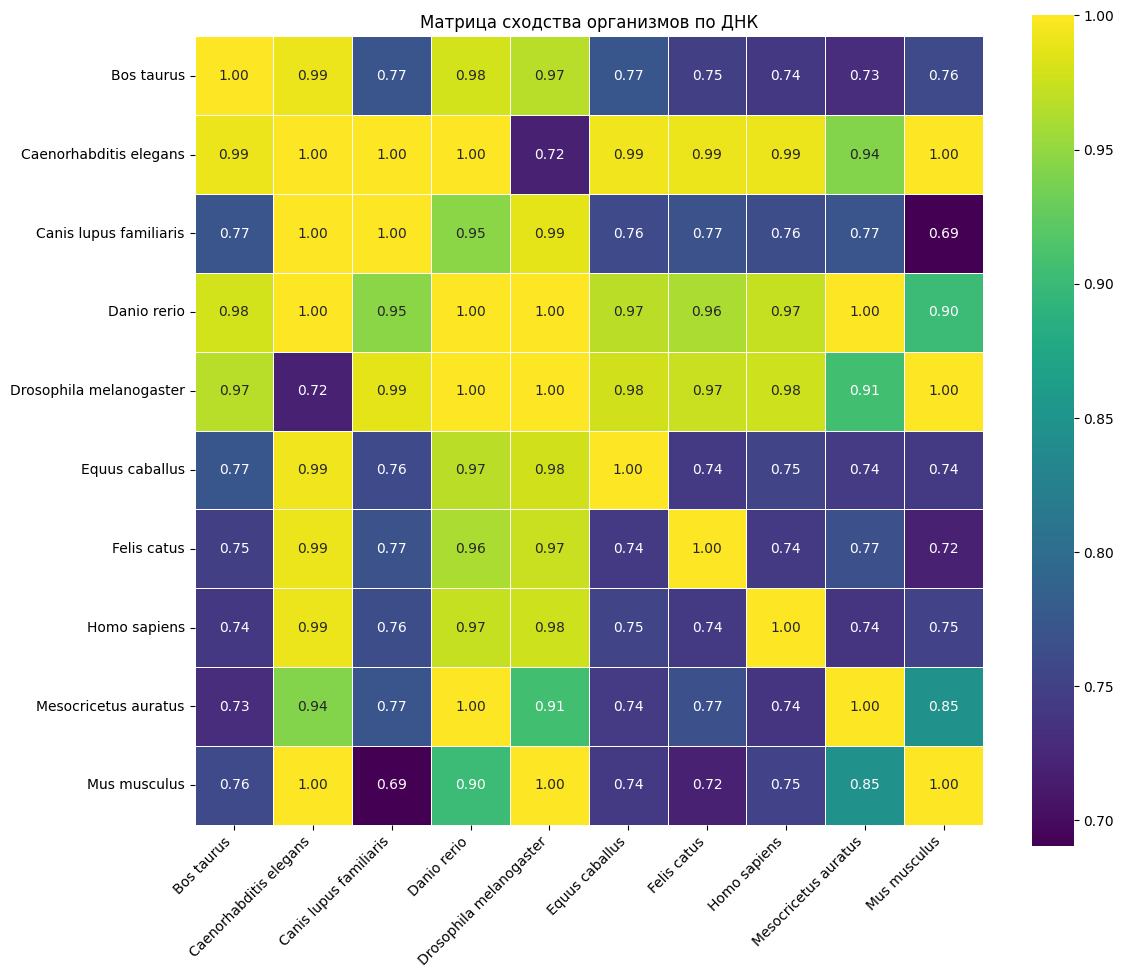

In [13]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    similarity_df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    square=True,
    linewidths=0.5,
)

plt.title("Матрица сходства организмов по ДНК")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
rank_df = build_rank_matrix(similarity_df)
rank_df

,Bos taurus,Caenorhabditis elegans,Canis lupus familiaris,Danio rerio,Drosophila melanogaster,Equus caballus,Felis catus,Homo sapiens,Mesocricetus auratus,Mus musculus
Bos taurus,1,2,6,3,4,5,8,9,10,7
Caenorhabditis elegans,6,1,4,2,10,5,7,8,9,3
Canis lupus familiaris,5,2,1,4,3,9,7,8,6,10
Danio rerio,5,1,9,2,3,7,8,6,4,10
Drosophila melanogaster,8,10,4,1,2,5,7,6,9,3
Equus caballus,5,2,6,4,3,1,10,7,8,9
Felis catus,7,2,5,4,3,8,1,9,6,10
Homo sapiens,9,2,5,4,3,6,8,1,10,7
Mesocricetus auratus,10,3,6,2,4,8,7,9,1,5
Mus musculus,6,1,10,4,2,8,9,7,5,3
